Central Limit Theorem

Import all the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the data

In [2]:
data = pd.read_excel('/content/fraud_data.xlsx')
data.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-04-01 00:58:00,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,2019-04-01 15:06:00,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,2019-04-01 22:37:00,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,2019-04-01 23:06:00,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,2019-04-01 23:59:00,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",1939-09-11 00:00:00,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1


Population Mean

In [3]:
population_mean = data['amt'].mean()
print(population_mean)

124.43007337671327


In [4]:
data.shape

(14446, 15)

Sample Mean

In [5]:
sample = data['amt'].sample(n=1000, random_state=42)
sample_mean = sample.mean()
print(sample_mean)

119.54582999999998


Impact of sample size on sample mean

Observation: As the sample size increases, the sample mean becomes a better estimate of the population mean. And this is one of the key ideas of the central limit theorem.

In [8]:
sample_sizes = [10, 50, 100, 500, 1000, 5000]

# list comprehension
sample_means = [data['amt'].sample(n=size, random_state=42).mean() for size in sample_sizes]

print(sample_means)

[np.float64(96.85499999999999), np.float64(88.3492), np.float64(81.8355), np.float64(112.06866000000001), np.float64(119.54582999999998), np.float64(123.99536800000001)]


In [9]:
for size, mean in zip(sample_sizes, sample_means):
  print(f"Sample size: {size}, Sample mean: {mean}")

Sample size: 10, Sample mean: 96.85499999999999
Sample size: 50, Sample mean: 88.3492
Sample size: 100, Sample mean: 81.8355
Sample size: 500, Sample mean: 112.06866000000001
Sample size: 1000, Sample mean: 119.54582999999998
Sample size: 5000, Sample mean: 123.99536800000001


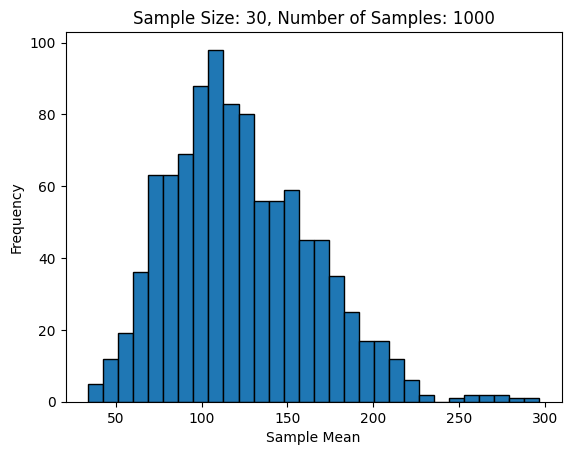

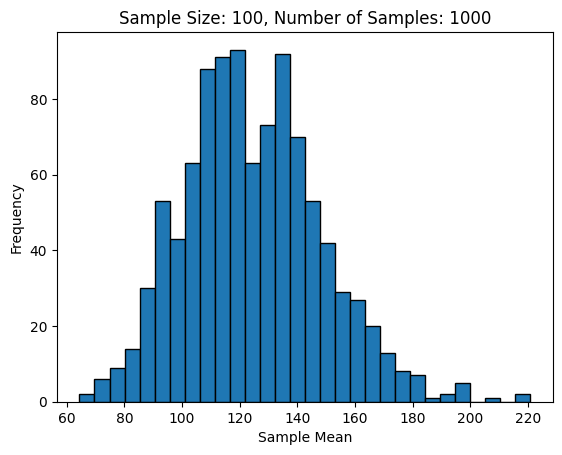

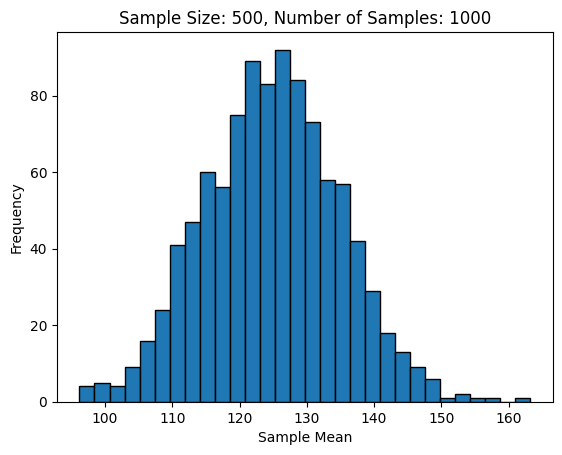

In [7]:
def visualize_clt(data, sample_size, num_samples):
  sample_means = [np.mean(np.random.choice(data, size=sample_size)) for i in range(num_samples)]
  # to observe the distribution of the data
  plt.hist(sample_means, bins=30, edgecolor='black')
  plt.title(f'Sample Size: {sample_size}, Number of Samples: {num_samples}')
  plt.xlabel('Sample Mean')
  plt.ylabel('Frequency')
  plt.show()


# function calling
visualize_clt(data['amt'], sample_size=30, num_samples=1000)
visualize_clt(data['amt'], sample_size=100, num_samples=1000)
visualize_clt(data['amt'], sample_size=500, num_samples=1000)

Z-Test

In [10]:
from scipy.stats import norm

population_mean = 800
sample_mean = 790
standard_error = 7.5
alpha = 0.05

z_score = (sample_mean - population_mean)/standard_error

p_value = 2 * norm.cdf(z_score)

if p_value > alpha:
  print('Fail to reject the null hypothesis: average lifespan of the light bulbs is approximately 800 hours')
else:
  print('Reject the null hypothesis: average lifespan of the light bulb is not 800 hours')

Fail to reject the null hypothesis: average lifespan of the light bulbs is approximately 800 hours


In [11]:
from scipy.stats import norm

population_mean = 20
sample_mean = 18.8
standard_error = 0.8
alpha = 0.05

z_score = (sample_mean - population_mean)/standard_error

p_value = 2 * norm.cdf(z_score)

if p_value > alpha:
  print('Fail to reject the null hypothesis: average lifespan of the light bulbs is approximately 800 hours')
else:
  print('Reject the null hypothesis: average lifespan of the light bulb is not 800 hours')

Fail to reject the null hypothesis: average lifespan of the light bulbs is approximately 800 hours
